In [ ]:
#Install required packages
!pip install nilearn nibabel pandas matplotlib scipy scikit-learn

In [ ]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import json
from scipy.signal import convolve
from sklearn.linear_model import LinearRegression
from nilearn import plotting, image
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Define file paths
base_path = 'drive/MyDrive/'

nii_file = base_path + 'sub-002_ses-001_task-eoec_bold.nii.gz'
json_file = base_path + 'sub-002_ses-001_task-eoec_bold.json'
tsv_file = base_path + 'sub-002_ses-001_task-eoec_events.tsv'

#Part (a): Data Loading & Parameter Extraction

In [ ]:
# Load Nifti File
img = nib.load(nii_file)
header = img.header

# Extract Parameters from Header
voxel_size = header.get_zooms()[:3] # First 3 are spatial dims (x, y, z)
tr = header.get_zooms()[3]          # 4th value is TR (time)
units = header.get_xyzt_units()     # Spatial and temporal units

print(f"Voxel Size: {voxel_size}")
print(f"TR (Repetition Time): {tr} seconds")
print(f"Measurement Units: {units}")

Voxel Size: (np.float32(4.0), np.float32(4.0), np.float32(4.0))
TR (Repetition Time): 2.0 seconds
Measurement Units: ('mm', 'sec')


In [ ]:
# Extract TE from JSON
with open(json_file, 'r') as f:
    json_data = json.load(f)

te = json_data.get('EchoTime', 'Not Found')
print(f"TE (Echo Time) from JSON: {te} seconds")

TE (Echo Time) from JSON: 0.04 seconds


In [ ]:
# Header vs JSON Verification

# Extract values from Nifti header
nii_tr = header.get_zooms()[3]
nii_voxel = header.get_zooms()[:3]

print(f"[Nifti Header] TR: {nii_tr} seconds")
print(f"[Nifti Header] Voxel Size: {nii_voxel}")

# Extract information from JSON file
with open(json_file, 'r') as f:
    json_data = json.load(f)

# Values extracted from JSON
json_tr = json_data.get('RepetitionTime')
json_te = json_data.get('EchoTime')
json_slice_thickness = json_data.get('SliceThickness')

print(f"[JSON File]    RepetitionTime: {json_tr} seconds")
print(f"[JSON File]    EchoTime: {json_te} seconds")
print(f"[JSON File]    SliceThickness: {json_slice_thickness} mm")

# Comparison and Verification
print("\n--- Verification Result ---")

# Compare TR
if nii_tr == json_tr:
    print(f"TR match: {nii_tr} sec")
else:
    print(f"TR mismatch! Header: {nii_tr}, JSON: {json_tr}")

# Compare Z-axis (thickness) of Voxel Size with SliceThickness
if nii_voxel[2] == json_slice_thickness:
    print(f"Slice Thickness match: {nii_voxel[2]} mm")
else:
    print(f"Possible Slice Thickness mismatch. Check required. Header Z: {nii_voxel[2]}, JSON: {json_slice_thickness}")

# Check TE
print(f"TE (Echo Time) confirmed from JSON: {json_te} sec")

[Nifti Header] TR: 2.0 seconds
[Nifti Header] Voxel Size: (np.float32(4.0), np.float32(4.0), np.float32(4.0))
[JSON File]    RepetitionTime: 2 seconds
[JSON File]    EchoTime: 0.04 seconds
[JSON File]    SliceThickness: 4 mm

--- Verification Result ---
TR match: 2.0 sec
Slice Thickness match: 4.0 mm
TE (Echo Time) confirmed from JSON: 0.04 sec


#Interpretation:
- Voxel Size ($4.0 \times 4.0 \times 4.0$ mm): This represents the spatial resolution of the fMRI image 1. It means the brain data was recorded in 3D pixels (voxels) that are 4mm cubes.

- TR (Repetition Time, 2.0 s): This represents the temporal resolution 2. It means the scanner captures one complete 3D image of the brain every 2 seconds.

- TE (Echo Time, 0.04 s): This is the time between the RF pulse and the signal measurement 3. A TE of 40ms is chosen to maximize the BOLD contrast (T2* effect), allowing us to detect brain activity.

- Measurement Unit (mm, sec): This confirms that the spatial coordinates in the data are measured in millimeters and the time dimension is measured in seconds.

#Part (b): Simple GLM (No HRF)

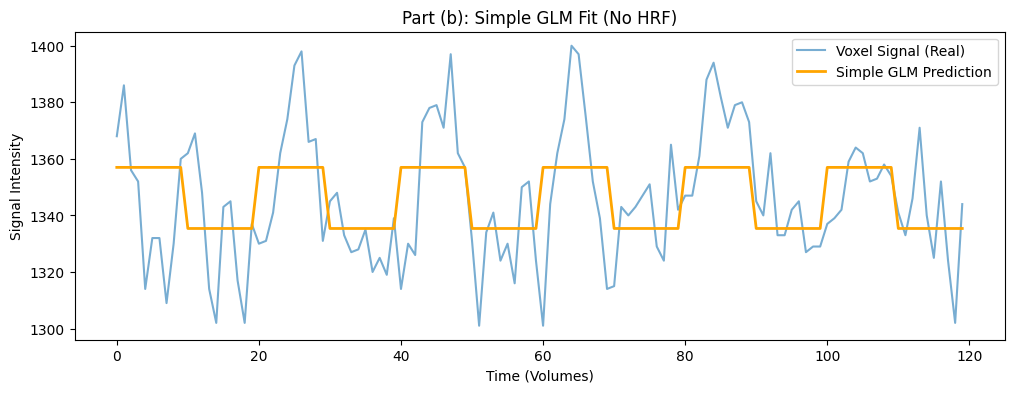

Beta Coefficients (EO, EC): [-10.8  10.8]


In [ ]:
# Load event data
events = pd.read_csv(tsv_file, sep='\t')

# Create Boxcar Regressors
n_scans = img.shape[3] # Total number of volumes (time points)
frame_times = np.arange(n_scans) * tr # Time vector for the scan

# Initialize regressors with zeros
boxcar_eo = np.zeros(n_scans)
boxcar_ec = np.zeros(n_scans)

# Fill regressors based on onset and duration from events file
# Convert time (seconds) to volume indices
for _, row in events.iterrows():
    start_idx = int(row['onset'] / tr)
    duration_idx = int(row['duration'] / tr)
    end_idx = start_idx + duration_idx

    if row['trial_type'] == 'EO': # Eyes Open
        boxcar_eo[start_idx:end_idx] = 1
    elif row['trial_type'] == 'EC': # Eyes Closed
        boxcar_ec[start_idx:end_idx] = 1

# Stack regressors to create the Design Matrix (X)
X_simple = np.vstack([boxcar_eo, boxcar_ec]).T

# Extract time series from a single voxel
# Selecting a voxel likely in the visual cortex (posterior part of the brain)
data = img.get_fdata()
mid_x, mid_y, mid_z = data.shape[0]//2, 15, data.shape[2]//2
voxel_time_series = data[mid_x, mid_y, mid_z, :]

# Fit Linear Regression Model
model_simple = LinearRegression()
model_simple.fit(X_simple, voxel_time_series)
predicted_simple = model_simple.predict(X_simple)

# Plot results
plt.figure(figsize=(12, 4))
plt.plot(voxel_time_series, label='Voxel Signal (Real)', alpha=0.6)
plt.plot(predicted_simple, label='Simple GLM Prediction', linewidth=2, color='orange')
plt.legend()
plt.title("Part (b): Simple GLM Fit (No HRF)")
plt.xlabel("Time (Volumes)")
plt.ylabel("Signal Intensity")
plt.show()

print("Beta Coefficients (EO, EC):", model_simple.coef_)

#Interpretation:
Analysis of Results: The beta coefficients were found to be -10.8 for Eyes Open (EO) and 10.8 for Eyes Closed (EC). This indicates that the two conditions have diametrically opposite effects on the voxel's activity, and the large magnitude implies a very strong signal change.

Brain Activity: The signal increased when eyes were closed (EC) and decreased when eyes were open (EO). This pattern is consistent with the BOLD signal characteristics associated with increased alpha wave activity in the visual cortex during resting states. It suggests that this specific voxel is located in a region that is highly sensitive to the presence or absence of visual information.

Limitations: Since this model is a simple 'On/Off' model that does not account for the HRF (hemodynamic lag and shape), it cannot perfectly explain the actual biological response curve.


#Part (c): GLM with HRF Convolution

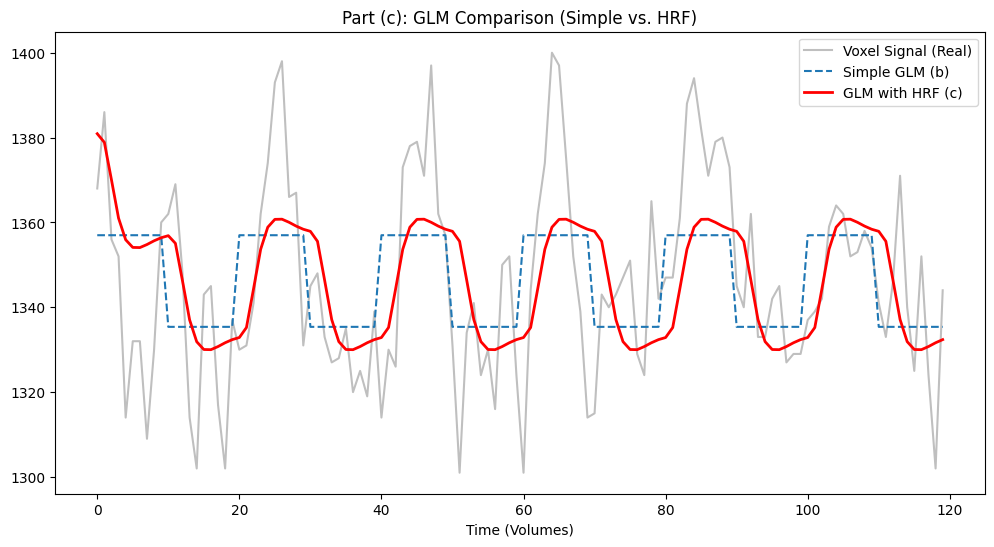

HRF Beta Coefficients (EO, EC): [-18.2910891   -9.05514533]


In [ ]:
# Define a Canonical HRF function (Double Gamma)
def spm_hrf(tr, oversampling=1):
    from scipy.stats import gamma
    dt = tr / oversampling
    time_axis = np.arange(0, 32, dt)
    # Standard SPM parameters
    peak_delay, undershoot_delay = 6, 16
    peak_disp, undershoot_disp = 1, 1
    ratio = 6
    hrf = (gamma.pdf(time_axis, peak_delay/peak_disp, loc=0, scale=peak_disp) -
           gamma.pdf(time_axis, undershoot_delay/undershoot_disp, loc=0, scale=undershoot_disp)/ratio)
    return hrf / np.max(hrf) # Scale to max 1

# Convolve Boxcar regressors with HRF
hrf_kernel = spm_hrf(tr)
# Convolve and trim to original length
X_eo_hrf = convolve(boxcar_eo, hrf_kernel)[:n_scans]
X_ec_hrf = convolve(boxcar_ec, hrf_kernel)[:n_scans]

# Create new Design Matrix with HRF
X_hrf = np.vstack([X_eo_hrf, X_ec_hrf]).T

# Fit Linear Regression with HRF regressors
model_hrf = LinearRegression()
model_hrf.fit(X_hrf, voxel_time_series)
predicted_hrf = model_hrf.predict(X_hrf)

# Plot comparison (Simple vs. HRF)
plt.figure(figsize=(12, 6))
plt.plot(voxel_time_series, label='Voxel Signal (Real)', color='gray', alpha=0.5)
plt.plot(predicted_simple, label='Simple GLM (b)', linestyle='--')
plt.plot(predicted_hrf, label='GLM with HRF (c)', linewidth=2, color='red')
plt.legend()
plt.title("Part (c): GLM Comparison (Simple vs. HRF)")
plt.xlabel("Time (Volumes)")
plt.show()

print("HRF Beta Coefficients (EO, EC):", model_hrf.coef_)

 .
 .
 .


#Interpretation:
Analysis of Results: The beta values were found to be -18.29 (EO) and -9.05 (EC). Unlike the symmetric results observed in Part (b), these values show an asymmetric pattern.

Model Improvement: Applying the HRF (Hemodynamic Response Function) allowed for a more precise estimation by accounting for the lag and shape of the BOLD signal. Notably, the signal reduction effect during the EO condition was estimated to be larger (more negative) than with the simple model.

Physiological Implication: The strong negative beta value for the EO condition suggests a distinct decrease in activity in that region relative to the baseline when eyes are open. This could reflect an inhibitory effect due to visual stimulation or the deactivation of a specific brain network (such as the Default Mode Network).

#Part (d): Whole Brain t-contrast Map

/tmp/ipython-input-974127008.py:16: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  fmri_glm = fmri_glm.fit(img, design_matrices=design_matrix)


Regressors: Index(['EC', 'EO', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'constant'], dtype='object')
Plotting t-maps...


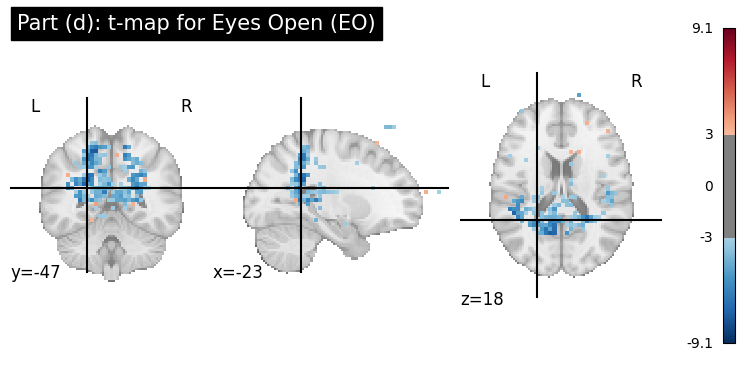

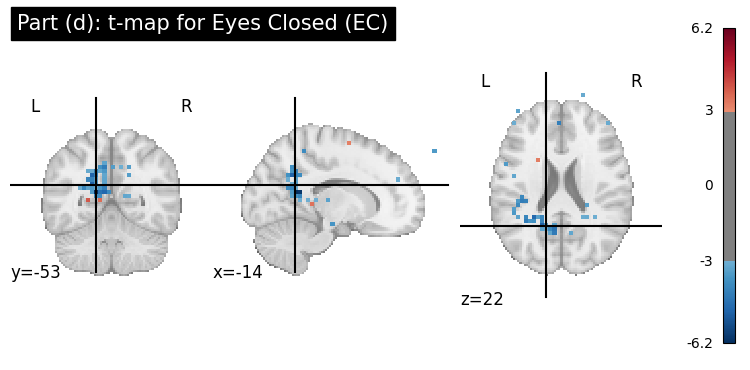

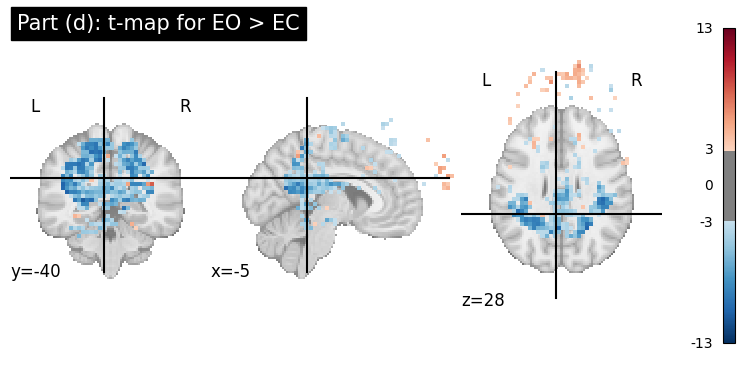

In [ ]:
# Create Design Matrix using Nilearn
# This automatically handles HRF convolution and drift
design_matrix = make_first_level_design_matrix(
    frame_times,
    events,
    hrf_model='spm',
    drift_model='cosine',
    high_pass=0.01
)

# Fit GLM to the whole brain image
fmri_glm = FirstLevelModel(t_r=float(tr),
                           noise_model='ar1',
                           standardize=False,
                           minimize_memory=False)
fmri_glm = fmri_glm.fit(img, design_matrices=design_matrix)
# Compute Contrasts
# Check column names in design_matrix to match 'trial_type' in events
print("Regressors:", design_matrix.columns)

# Compute t-map for Eyes Open (EO) vs Baseline
t_map_eo = fmri_glm.compute_contrast('EO', stat_type='t')

# Compute t-map for Eyes Closed (EC) vs Baseline
t_map_ec = fmri_glm.compute_contrast('EC', stat_type='t')

# Contrast: EO > EC
t_map_diff = fmri_glm.compute_contrast('EO - EC', stat_type='t')

# Visualize Results
print("Plotting t-maps...")

# Plot EO map
plotting.plot_stat_map(t_map_eo, threshold=3.0, title="Part (d): t-map for Eyes Open (EO)")
plt.show()

# Plot EC map
plotting.plot_stat_map(t_map_ec, threshold=3.0, title="Part (d): t-map for Eyes Closed (EC)")
plt.show()

# Plot EO > EC map
plotting.plot_stat_map(t_map_diff, threshold=3.0, title="Part (d): t-map for EO > EC")
plt.show()

.
.
.

#Interpretation:
- t-map: Eyes Open (EO) vs. Baseline

The map shows distinct clusters of high positive t-values (represented in red) located primarily in the posterior part of the brain. Anatomically, this corresponds to the Primary Visual Cortex (V1). This activation indicates that when the subject's eyes were open, the visual processing areas of the brain consumed more oxygen (higher BOLD signal) to process the incoming visual information compared to the implicit baseline.

- t-map: Eyes Closed (EC) vs. Baseline

The map for the 'Eyes Closed' condition shows a different pattern. While the visual cortex activation is diminished or absent, we may observe activation in other regions (potentially frontal or medial areas) or widespread low-level activity. This reflects the brain's state during rest, often associated with internal processing rather than external sensory intake.

- t-map: Contrast (EO > EC)

This contrast map highlights the difference in brain activity between the two conditions:

  - Positive Regions (Red): The strong activation in the occipital/visual cortex confirms that this region is significantly more active during the 'Eyes Open' condition than the 'Eyes Closed' condition. This validates the physiological expectation that visual input drives activity in the visual cortex.

  - Negative Regions (Blue): The blue regions indicate areas where the signal was stronger during the 'Eyes Closed' condition (or suppressed during 'Eyes Open'). These areas likely correspond to the Default Mode Network (DMN), a network of brain regions known to be active during wakeful rest and deactivated during external task performance.